# Part 5

In [4]:
import redis
import pandas as pd
import matplotlib.pyplot as plt

REDIS_KEY_PREFIX = 'journey:gyro'

r = redis.Redis(host='localhost', port=6379)
keys = r.keys(f'{REDIS_KEY_PREFIX}:*')
print(f"Gefundene Keys in Redis: {len(keys)}")

Gefundene Keys in Redis: 28


In [5]:
records = []
for key in keys:
    data = r.hgetall(key)
    decoded = {k.decode('utf-8'): v.decode('utf-8') for k, v in data.items()}
    records.append(decoded)

df = pd.DataFrame(records)
df['avg_absolute']  = df['avg_absolute'].astype(float)
df['avg_gx']        = df['avg_gx'].astype(float)
df['avg_gy']        = df['avg_gy'].astype(float)
df['avg_gz']        = df['avg_gz'].astype(float)
df['n_samples']     = df['n_samples'].astype(int)
df['fenster_start'] = pd.to_datetime(df['fenster_start'])
df = df.sort_values('fenster_start').reset_index(drop=True)

print(f"Geladene Fenster: {len(df)}")
df[['fenster_start', 'avg_gx', 'avg_gy', 'avg_gz', 'avg_absolute', 'n_samples']].head(10)

ValueError: cannot convert float NaN to integer

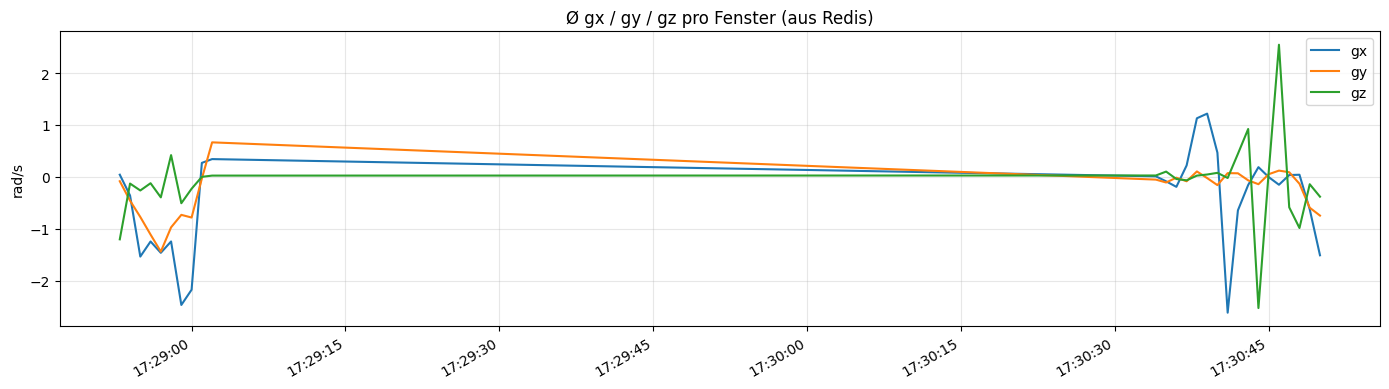

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df['fenster_start'], df['avg_gx'], label='gx')
ax.plot(df['fenster_start'], df['avg_gy'], label='gy')
ax.plot(df['fenster_start'], df['avg_gz'], label='gz')
ax.set_title('Ø gx / gy / gz pro Fenster (aus Redis)')
ax.set_ylabel('rad/s')
ax.legend()
ax.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()
